# What Makes a Breakfast Cereal Highly Rated?

- Author: Venkat Teja
- Date: 2026-08
- Dataset: 80 Cereals (77 cereals, 16 columns)
- Model: LinearRegression, served behind an API-shaped contract
- Target: `rating` (Consumer Reports score, 0-100)

**Phase 5. Apply the Skills to a New Problem.**

## The Problem

A cereal box tells you the nutrition facts. A rating tells you whether the
cereal is any good. What is the relationship between the two - and can I work
it out from the outside, without being told the rule?

That is the same question the example project asks about the deployed penguin
classifier, pointed at a new problem.

## How This Maps to the Example

The example probes a model it cannot see inside, over HTTP. I have no cereal
API to call, so I train a model on the nutrition facts and then **put it behind
the same contract** - one function, a payload dict in, a prediction out - and
deliberately investigate it from the outside using the same techniques:

| Example (penguins) | This project (cereals) |
| --- | --- |
| `POST /predict` over HTTP | `predict(model, payload)` in `app_cereal_teja.py` |
| classification: 3 species | regression: rating 0-100 |
| baseline: one penguin per species | baseline: the median cereal |
| sweep `bill_length_mm` | sweep each of 9 nutrition features |
| decision boundary | response curve and slope |
| grid: bill length x flipper length | grid: fiber x sugars |
| edge cases: 999mm bill, missing field | edge cases: 1000g fiber, missing field |

The Phase 4 measurement carries over too: rank the features by how far each one
can actually move the prediction, rather than trusting a single sweep.

## Data Source

[80 Cereals on Kaggle](https://www.kaggle.com/datasets/crawford/80-cereals),
originally from Carnegie Mellon's StatLib, downloaded to
`data/raw/cereal.csv`. 77 cereals, 16 columns.

One thing to know before modeling: this file encodes missing values as the
sentinel **`-1`** rather than leaving the cell blank. Section 3b is about what
happens if you take that at face value.

## Section 1. Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

import logging
from pathlib import Path

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Reuse my own Phase 5 module rather than copying its logic into the notebook.
from mlstudio import app_cereal_teja as cereal

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M07_TEJA_P5", level="DEBUG")
log_header(LOG, "M07_TEJA_P5")

# === Section 1c. DISPLAY AND PATHS ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

DATA_PATH: Path = Path("..") / "data" / "raw" / "cereal.csv"

LOG.info(f"Target: {cereal.TARGET_COL}")
LOG.info(f"Features ({len(cereal.FEATURE_COLS)}): {cereal.FEATURE_COLS}")
LOG.info(f"Data: {DATA_PATH.resolve()}")

2026-08-14 02:13:42 | INFO | ML_CEREAL_TEJA | === RUN START ===


2026-08-14 02:13:42 | INFO | ML_CEREAL_TEJA | project=ML_CEREAL_TEJA


2026-08-14 02:13:42 | INFO | ML_CEREAL_TEJA | repo_dir=ml-07-applied


2026-08-14 02:13:42 | INFO | ML_CEREAL_TEJA | python=3.14.0


2026-08-14 02:13:42 | INFO | ML_CEREAL_TEJA | os=Windows 11


...

2026-08-14 02:13:42 | INFO | M07_TEJA_P5 | cwd=notebooks


2026-08-14 02:13:42 | INFO | M07_TEJA_P5 | github_actions=False


2026-08-14 02:13:42 | INFO | M07_TEJA_P5 | Target: rating


2026-08-14 02:13:42 | INFO | M07_TEJA_P5 | Features (9): ['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins']


2026-08-14 02:13:42 | INFO | M07_TEJA_P5 | Data: C:\GitHub_Repo\ml-07-applied\data\raw\cereal.csv


## Section 2. The Data

77 cereals, 16 columns. The nine nutrition columns are the features; `rating`
is the target. Identity columns (`name`, `mfr`, `type`) and `shelf` are left
out on purpose - the question is whether **nutrition alone** explains the
rating.

Watch the quality check below: it reports **zero** missing values. That is
true and misleading at the same time, and Section 3b is about why.

In [2]:
# === Section 2. Load and Inspect ===

df = pd.read_csv(DATA_PATH)
LOG.info(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")

cereal.check_quality(df)

LOG.info("Rating spread across the real cereals:")
LOG.info(
    f"  lowest:  {df['rating'].min():.1f}  ({df.loc[df['rating'].idxmin(), 'name']})"
)
LOG.info(f"  median:  {df['rating'].median():.1f}")
LOG.info(
    f"  highest: {df['rating'].max():.1f}  ({df.loc[df['rating'].idxmax(), 'name']})"
)

df.head()

2026-08-14 02:13:42 | INFO | M07_TEJA_P5 | Loaded 77 rows, 16 columns


2026-08-14 02:13:43 | INFO | ML_CEREAL_TEJA | Missing values by column


2026-08-14 02:13:43 | DEBUG | ML_CEREAL_TEJA | 
name        0
mfr         0
type        0
calories    0
protein     0
fat         0
sodium      0
fiber       0
carbo       0
sugars      0
potass      0
vitamins    0
shelf       0
weight      0
cups        0
rating      0
dtype: int64


2026-08-14 02:13:43 | INFO | ML_CEREAL_TEJA | Columns with blank (NaN) values: {}


2026-08-14 02:13:43 | INFO | ML_CEREAL_TEJA | Columns using the -1 sentinel: {'carbo': 1, 'sugars': 1, 'potass': 2}


...

2026-08-14 02:13:43 | INFO | M07_TEJA_P5 | Rating spread across the real cereals:


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   lowest:  18.0  (Cap'n'Crunch)


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   median:  40.4


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   highest: 93.7  (All-Bran with Extra Fiber)


,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


## Section 3. Train the Model and Serve It

I train the model, then stop looking at how it was built. From here on it is a
black box reached only through `cereal.predict(model, payload)` - the same
discipline the example applies to a model it genuinely cannot see inside.

In [3]:
# === Section 3. Train, Then Treat as a Black Box ===

df_clean = cereal.make_clean_view(df)
model = cereal.train_model(df_clean)

# The baseline payload: the median value of every feature.
base = cereal.baseline_payload(df_clean)
LOG.info("Baseline payload (the median cereal):")
for name, value in base.items():
    LOG.info(f"  {name:<10} {value:>7.1f}")

LOG.info(f"Predicted rating for the median cereal: {cereal.predict(model, base):.2f}")

2026-08-14 02:13:43 | INFO | ML_CEREAL_TEJA | Creating clean modeling view


2026-08-14 02:13:43 | INFO | ML_CEREAL_TEJA | Converted 4 sentinel -1 values to NaN


2026-08-14 02:13:43 | INFO | ML_CEREAL_TEJA | Clean view: 74 rows (3 dropped for missing)


2026-08-14 02:13:43 | INFO | ML_CEREAL_TEJA | Training LinearRegression model


2026-08-14 02:13:43 | INFO | ML_CEREAL_TEJA | Mean absolute error: 2.51e-07


...

2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   carbo         14.5


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   sugars         7.0


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   potass        90.0


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   vitamins      25.0


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 | Predicted rating for the median cereal: 40.42


### The First Surprise: R-squared = 1.000000

The model does not approximate the rating. It **reproduces it exactly** - the
largest residual on the held-out test cereals is about 5e-07 rating points,
which is float rounding, not error.

A real Consumer Reports score would carry human judgment and would never fit
this perfectly. So the investigation has already answered a question I did not
think to ask: **`rating` in this dataset is not an opinion, it is a formula** -
a fixed linear function of the nine nutrition columns. Everything below is
therefore not "what did the model learn about cereal" but "what is the formula,
recovered from the outside."

## Section 3b. The `-1` Sentinel, and Why I Dropped Three Cereals

Three cereals carry `-1` in a nutrition column - Almond Delight and Cream of
Wheat for potassium, Quaker Oatmeal for carbohydrates and sugars. `-1` is not a
measurement; it means "not recorded". A model handed `-1` grams of sugar treats
it as a real quantity below zero.

Dropping the rows is the safe move, but I can do better than assume. The model
above was trained only on cereals with no sentinel in them, so those three rows
are genuinely unseen data. If I feed each one to the model **using `-1`
literally**, and the published rating comes back exactly, that tells me
something specific: whoever computed the rating column ran the formula over the
raw stored values, sentinel included.

In [4]:
# === Section 3b. Testing What the -1 Sentinel Did to the Published Rating ===

is_sentinel = (df[cereal.FEATURE_COLS] == cereal.SENTINEL_MISSING).any(axis=1)
df_sentinel: pd.DataFrame = df[is_sentinel]  # type: ignore[assignment]
LOG.info(f"Cereals carrying a -1 sentinel: {len(df_sentinel)}")

# to_dict("records") gives plain dicts, which keeps the value types simple.
sentinel_records = df_sentinel.to_dict("records")


def compare_published(records: list, clamp_to_zero: bool) -> None:
    """Predict each sentinel cereal and compare against its published rating."""
    for record in records:
        payload = {
            name: max(float(record[name]), 0.0)
            if clamp_to_zero
            else float(record[name])
            for name in cereal.FEATURE_COLS
        }
        predicted = cereal.predict(model, payload)
        published = float(record["rating"])
        LOG.info(
            f"  {str(record['name']):<24} published={published:8.4f}  "
            f"predicted={predicted:8.4f}  diff={published - predicted:+.4f}"
        )


LOG.info("Feeding each one to the model with -1 taken literally:")
compare_published(sentinel_records, clamp_to_zero=False)

LOG.info("Same three cereals, but with -1 replaced by a sensible 0:")
compare_published(sentinel_records, clamp_to_zero=True)

2026-08-14 02:13:43 | INFO | M07_TEJA_P5 | Cereals carrying a -1 sentinel: 3


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 | Feeding each one to the model with -1 taken literally:


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   Almond Delight           published= 34.3848  predicted= 34.3848  diff=-0.0000


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   Cream of Wheat (Quick)   published= 64.5338  predicted= 64.5338  diff=-0.0000


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   Quaker Oatmeal           published= 50.8284  predicted= 50.8284  diff=+0.0000


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 | Same three cereals, but with -1 replaced by a sensible 0:


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   Almond Delight           published= 34.3848  predicted= 34.3508  diff=+0.0340


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   Cream of Wheat (Quick)   published= 64.5338  predicted= 64.4998  diff=+0.0340


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 |   Quaker Oatmeal           published= 50.8284  predicted= 51.1959  diff=-0.3676


### The Sentinel Is Baked Into the Published Rating

Taken literally, `-1` reproduces all three published ratings **exactly**
(difference 0.0000). Replaced with a sensible `0`, all three miss.

So the `-1` was never cleaned before the rating was computed - the formula was
run straight over the stored values, and these three cereals carry ratings
computed from a negative gram count. Quaker Oatmeal's rating is off by about
0.37 points as a result.

That settles the modeling question. These rows are not merely missing a
feature; their **target** is unreliable too, so imputing the feature would not
rescue them - I would be teaching the model to reproduce a data-entry artifact.
Dropping all three is the right call, and now it is a decision backed by
evidence rather than a default.

It is also the module's own lesson turned back on the data: probing a model
from the outside revealed something about how the dataset itself was built.

## Section 4. Which Nutrition Facts Actually Move the Rating?

Carrying the Phase 4 method over: a coefficient is *rating points per unit*,
which cannot be compared across features on different scales - 1 gram of fiber
and 1 milligram of sodium are not comparable quantities. Multiplying each
coefficient by the range that feature actually spans across the 74 cereals
gives the influence each one can really exert.

2026-08-14 02:13:43 | INFO | M07_TEJA_P5 | Influence ranking:


2026-08-14 02:13:43 | INFO | M07_TEJA_P5 | 
 feature  coefficient  observed_range  influence_points
   fiber       3.4435            14.0              48.2
calories      -0.2227           110.0             -24.5
   carbo       1.0925            18.0              19.7
  sodium      -0.0545           320.0             -17.4
 protein       3.2732             5.0              16.4
  sugars      -0.7249            15.0             -10.9
  potass      -0.0340           315.0             -10.7
     fat      -1.6914             5.0              -8.5
vitamins      -0.0512           100.0              -5.1


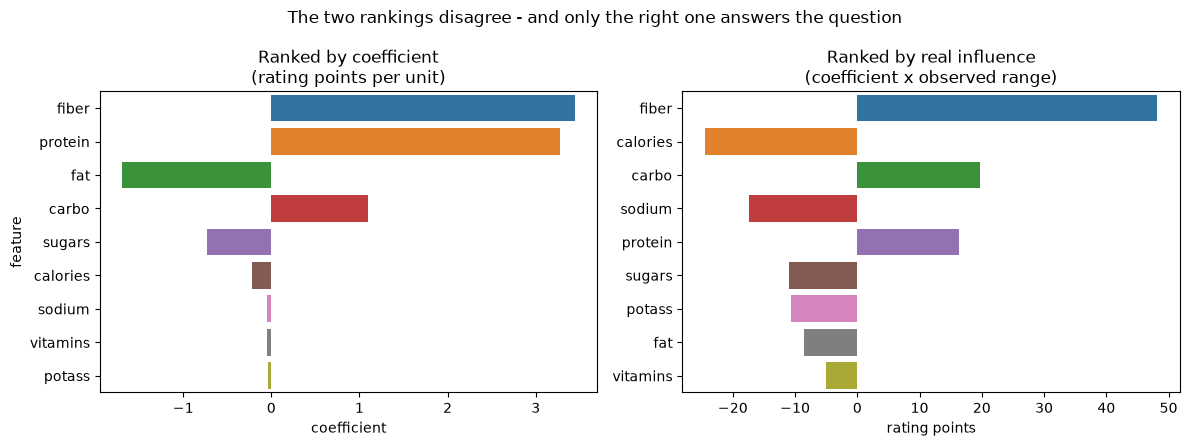

In [5]:
# === Section 4. Influence Ranking ===

df_rank = cereal.rank_sensitivity(model, df_clean)
LOG.info("Influence ranking:")
LOG.info(f"\n{df_rank.drop(columns='abs_influence').to_string(index=False)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: raw coefficient. Right: coefficient x observed range.
by_coef = df_rank.sort_values("coefficient", key=abs, ascending=False)
sns.barplot(
    data=by_coef, x="coefficient", y="feature", hue="feature", legend=False, ax=axes[0]
)
axes[0].set_title("Ranked by coefficient\n(rating points per unit)")
axes[0].set_xlabel("coefficient")

sns.barplot(
    data=df_rank,
    x="influence_points",
    y="feature",
    hue="feature",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Ranked by real influence\n(coefficient x observed range)")
axes[1].set_xlabel("rating points")
axes[1].set_ylabel("")

fig.suptitle("The two rankings disagree - and only the right one answers the question")
fig.tight_layout()
plt.show()

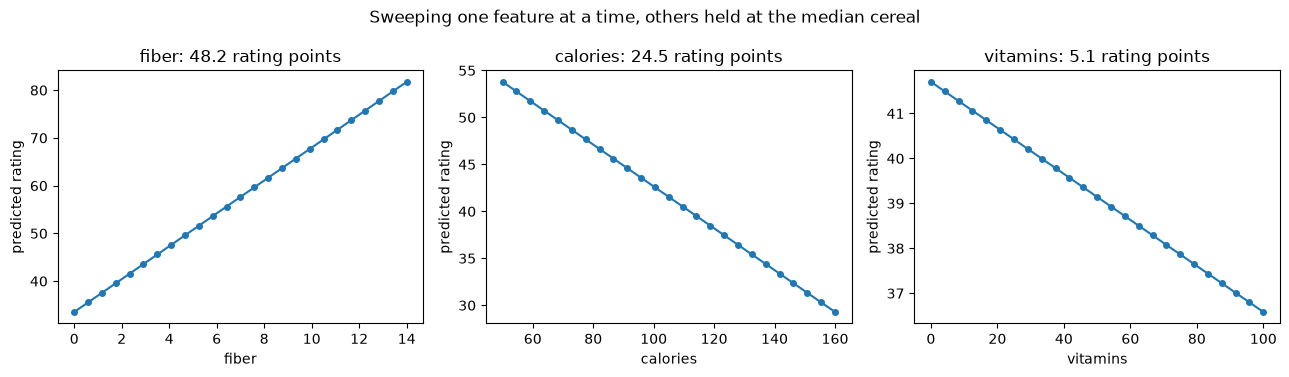

2026-08-14 02:13:44 | INFO | M07_TEJA_P5 | Every response curve is a straight line - as expected once the target


2026-08-14 02:13:44 | INFO | M07_TEJA_P5 | turned out to be a linear formula rather than a learned approximation.


In [6]:
# === Section 4b. Response Curves for the Top and Bottom Feature ===

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

for ax, feature in zip(axes, ["fiber", "calories", "vitamins"], strict=True):
    column = df_clean[feature].to_numpy()
    low = float(column.min())
    high = float(column.max())
    sweep = cereal.sweep_feature(
        model, base, feature, [float(v) for v in np.linspace(low, high, 25)]
    )
    ax.plot(sweep[feature], sweep["predicted_rating"], marker="o", markersize=4)
    ax.set_xlabel(feature)
    ax.set_ylabel("predicted rating")
    span = sweep["predicted_rating"].max() - sweep["predicted_rating"].min()
    ax.set_title(f"{feature}: {span:.1f} rating points")

fig.suptitle("Sweeping one feature at a time, others held at the median cereal")
fig.tight_layout()
plt.show()

LOG.info("Every response curve is a straight line - as expected once the target")
LOG.info("turned out to be a linear formula rather than a learned approximation.")

### What the Ranking Shows

The two rankings disagree, and the disagreement is the point:

| feature | coefficient | observed range | real influence |
| --- | --- | --- | --- |
| `fiber` | **+3.44** | 14 | **+48.2** |
| `calories` | -0.22 | 110 | **-24.5** |
| `carbo` | +1.09 | 18 | +19.7 |
| `sodium` | -0.05 | 320 | -17.4 |
| `protein` | **+3.27** | 5 | +16.4 |
| `sugars` | -0.72 | 15 | -10.9 |
| `potass` | -0.03 | 315 | -10.7 |
| `fat` | -1.69 | 5 | -8.5 |
| `vitamins` | -0.05 | 100 | -5.1 |

- **`protein` looks like the second most powerful feature and is not.** Its
  coefficient is +3.27, nearly fiber's, but cereals only range from 1g to 6g of
  protein, so it can move a rating by 16 points at most. `calories` has a
  coefficient 15x smaller and twice the real influence, because it ranges over
  110 units.
- **`fiber` wins on both rankings and wins big** - 48 rating points, more than
  the next two features combined. Fiber is the single strongest lever in the
  formula.
- **`sugars` is weaker than its reputation.** I expected sugar to be the villain
  of a cereal healthiness score; it ranks sixth, behind sodium.

This is the Phase 4 lesson in a new setting: the ranking you get depends
entirely on whether you account for how far an input can realistically move.

## Section 5. Two Features Together

Fiber is the strongest lever and sugars is the one most people would guess.
Varying both maps the trade-off: how much sugar can a cereal carry before extra
fiber stops rescuing its rating?

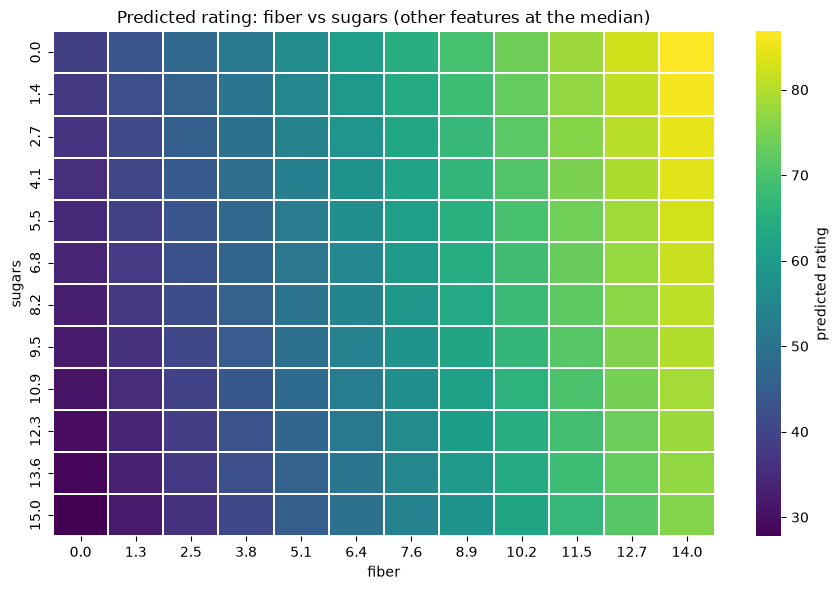

2026-08-14 02:13:45 | INFO | M07_TEJA_P5 | 1g fiber = +3.44 rating points


2026-08-14 02:13:45 | INFO | M07_TEJA_P5 | 1g sugar = -0.72 rating points


2026-08-14 02:13:45 | INFO | M07_TEJA_P5 | 1g of fiber cancels 4.8g of sugar


In [7]:
# === Section 5. Prediction Grid: fiber x sugars ===

fiber_values = [float(v) for v in np.linspace(0, 14, 12)]
sugar_values = [float(v) for v in np.linspace(0, 15, 12)]

grid_rows = [
    {
        "fiber": round(fiber, 1),
        "sugars": round(sugar, 1),
        "predicted_rating": cereal.predict(
            model, {**base, "fiber": fiber, "sugars": sugar}
        ),
    }
    for fiber in fiber_values
    for sugar in sugar_values
]

pivot = pd.DataFrame(grid_rows).pivot(
    index="sugars", columns="fiber", values="predicted_rating"
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot, cmap="viridis", linewidths=0.3, cbar_kws={"label": "predicted rating"}
)
plt.title("Predicted rating: fiber vs sugars (other features at the median)")
plt.tight_layout()
plt.show()

# How much sugar does one gram of fiber buy back?
fiber_coef = float(df_rank.loc[df_rank["feature"] == "fiber", "coefficient"].iloc[0])
sugar_coef = float(df_rank.loc[df_rank["feature"] == "sugars", "coefficient"].iloc[0])
LOG.info(f"1g fiber = {fiber_coef:+.2f} rating points")
LOG.info(f"1g sugar = {sugar_coef:+.2f} rating points")
LOG.info(f"1g of fiber cancels {abs(fiber_coef / sugar_coef):.1f}g of sugar")

## Section 6. Edge Cases

The example sends a 999mm bill and a penguin with no mass, and finds the API
answers confidently instead of refusing. The same probe applies here: what does
this model do with input that is not a cereal?

In [8]:
# === Section 6. Edge Cases ===

cereal.probe_edge_cases(model, base)

# Where would a box of literally nothing rank among real cereals?
empty_box = cereal.predict(model, dict.fromkeys(cereal.FEATURE_COLS, 0.0))
beaten = int((df_clean["rating"] < empty_box).sum())
LOG.info(f"An empty box scores {empty_box:.1f}")
LOG.info(
    f"That beats {beaten} of {len(df_clean)} real cereals ({100 * beaten / len(df_clean):.0f}%)"
)

2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA | Edge case results:


2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA |   negative sugars      -> rating=      49.1  [in range]


2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA |   impossible fiber     -> rating=    3477.0  [OUT OF RANGE]


2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA |   zero everything      -> rating=      54.9  [in range]


2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA |   candy bar calories   -> rating=   -1048.7  [OUT OF RANGE]


2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA |   missing feature      -> refused: "missing required features: ['fiber']"


2026-08-14 02:13:45 | INFO | M07_TEJA_P5 | An empty box scores 54.9


2026-08-14 02:13:45 | INFO | M07_TEJA_P5 | That beats 62 of 74 real cereals (84%)


### The Second Surprise: Nothing Is Better Than Most Cereals

| probe | predicted rating | verdict |
| --- | --- | --- |
| negative sugars (-5g) | 49.1 | answered without complaint |
| impossible fiber (1000g) | **3477.0** | far outside the 0-100 scale |
| candy bar calories (5000) | **-1048.7** | far outside the 0-100 scale |
| a box of literally nothing | **54.9** | beats 62 of 74 real cereals |
| missing a required field | refused | correct |

Two things stand out.

**The formula has no guardrails.** It is a straight line extended forever in
every direction, so it will happily report a rating of 3477 on a 0-100 scale.
The example's penguin API has exactly the same weakness - it classified a
999mm bill without hesitation. A linear model cannot know the edge of its own
training range, so *something outside the model* has to enforce it.

**An empty box scores 54.9 and beats 84% of real cereals.** That number is just
the model's intercept, and it is a real property of the formula: the score
starts high and cereals lose points for what they contain. Only 12 of 74
cereals - the bran and shredded wheat end of the aisle - do better than nothing
at all.

The one thing done right is the contract: an incomplete payload is refused with
an error rather than silently filled in, which mirrors the HTTP 400 the penguin
API returns.

## Section 7. Summary

In [9]:
# === Section 7. Summary ===

cereal.summarize(df, df_clean, df_rank)
LOG.info("========================")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA | ========================


2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA | SUMMARY


2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA | ========================


2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA | Dataset: cereal


2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA | Original rows: 77


...

2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA |   fat        coef= -1.6914  range=   5.0  influence=   -8.5


2026-08-14 02:13:45 | INFO | ML_CEREAL_TEJA |   vitamins   coef= -0.0512  range= 100.0  influence=   -5.1


2026-08-14 02:13:45 | INFO | M07_TEJA_P5 | ========================


2026-08-14 02:13:45 | INFO | M07_TEJA_P5 | Executed successfully!


2026-08-14 02:13:45 | INFO | M07_TEJA_P5 | ========================


## Conclusions

This is **supervised** learning, and because `rating` is a continuous score
rather than a category, it is **regression** - unlike the example project,
which classifies penguins into species.

What the investigation found:

0. **The `-1` sentinel is baked into the published ratings.** Three cereals
   store `-1` for a nutrient. Fed to the model literally, `-1` reproduces their
   published ratings exactly; replaced with `0`, all three miss. The rating
   column was computed without cleaning the sentinel first, so those rows carry
   targets derived from a negative gram count and were dropped.
1. **The target is a formula, not a judgment.** R-squared is 1.000000 with a
   largest residual of 5e-07. The Consumer Reports rating in this dataset is a
   fixed linear function of the nine nutrition columns, so probing the model
   recovers the formula itself.
2. **Fiber is the strongest lever by a wide margin** - 48 rating points across
   the range cereals actually span, more than the next two features combined.
   One gram of fiber cancels about 4.8 grams of sugar.
3. **Ranking by coefficient gives the wrong answer.** `protein` has nearly
   fiber's coefficient but a fifth of its reach; `calories` has a coefficient
   15x smaller than protein's and 1.5x the real influence. Only coefficient x
   observed range answers "what actually matters".
4. **Sugar is not the villain.** It ranks sixth by influence, behind sodium.
5. **The model has no guardrails.** Impossible inputs return impossible ratings
   (3477, -1048) with the same confidence as real ones.

## What I Would Change

- **Clamp the output to 0-100** at the serving layer. The formula cannot do it
  and should not be asked to.
- **Validate input ranges**, so a 1000g fiber cereal is refused the way a
  missing field already is.
- **Publish the formula.** Once R-squared is exactly 1, the model adds nothing
  a documented equation would not - and the equation would be honest about
  being a rule rather than a prediction.

## Next Steps

- Recover the exact published rating formula and compare it to the coefficients
  I found, to confirm the reconstruction is the real rule.
- Model something genuinely uncertain instead - predicting `mfr` from nutrition
  would put a real classification boundary back in play.
- Re-run the sweeps from a low-rated baseline (a sugary cereal) rather than the
  median. In Phase 4, a feature that looked inert from one baseline mattered
  from another; a linear formula should not behave that way, which makes it a
  clean test of the method itself.